In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import ex_duffing
import reinforcement_learning as rl

In [2]:
# --! duffing environments --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

dt = 2e-2
setpoint = [1.0, 0.0]

reward_nom = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_exc = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('nom', reward_nom, dt=dt))
duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('exc', reward_exc, dt=dt))

In [3]:
# --! make a base policy --!

base_policy = ex_duffing.make_base_policy(
    duffing_nom.env.alpha, duffing_nom.env.delta,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)

In [4]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '15',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)


In [5]:
# --! create factories --!

dataset_factory = ex_duffing.dataset_factory(setpoint)
replay_factory = ex_duffing.replay_factory()

In [6]:
agent = rl.agent(kind.regimes(duffing_nom, duffing_exc), base_policy, dataset_factory, replay_factory, args)


creating new normalizer


saving data with a shape torch.Size([1, 3848, 4]) to a file
saving data with a shape torch.Size([1, 3848, 4]) to a file
1
>>> training nominal mean >>>
	epoch 1 losses: train=0.256344, valid=0.239233, test=0.239204
	validation loss decreased (inf -> 0.239233), saving model ...
	epoch 2 losses: train=0.172610, valid=0.105739, test=0.099953
	validation loss decreased (0.239233 -> 0.105739), saving model ...
	epoch 3 losses: train=0.028190, valid=0.002117, test=0.002133
	validation loss decreased (0.105739 -> 0.002117), saving model ...
	epoch 4 losses: train=0.000914, valid=0.000426, test=0.000408
	validation loss decreased (0.002117 -> 0.000426), saving model ...
	epoch 5 losses: train=0.000282, valid=0.000179, test=0.000182
	validation loss decreased (0.000426 -> 0.000179), saving model ...
	epoch 6 losses: train=0.000142, valid=0.000107, test=0.000105
	validation loss decreased (0.000179 -> 0.000107), saving model ...
	epoch 7 losses: train=0.000087, valid=0.000073, test=0.000074
	val

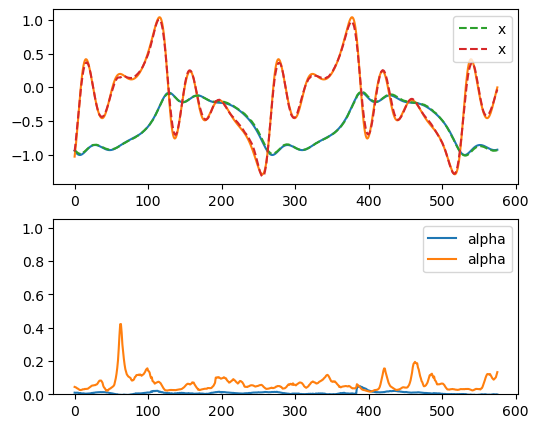

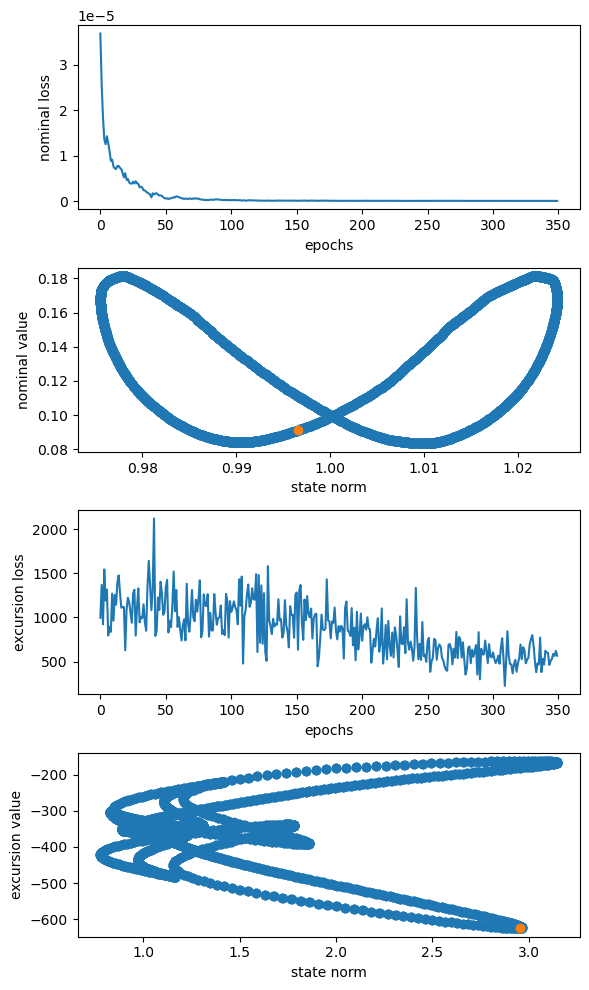

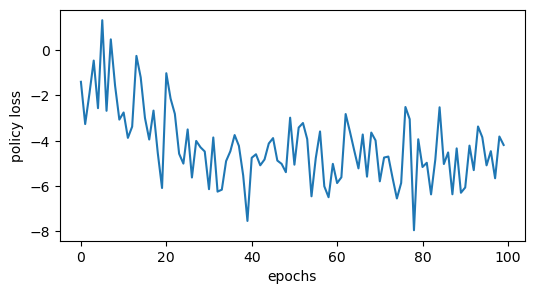

In [7]:
agent.train()